# Construcción del dataset con target de riesgo a 20 días

**TFM:** estimación de riesgo de mercado con Machine Learning.

Este notebook parte del dataset base (`initial_market_dataset.csv`) y genera una **nueva versión** con el target de riesgo futuro, guardada en `dataset_with_target.csv`.

- **No** se sobrescribe el dataset base.
- **No** se entrenan modelos en esta fase.
- Las features siguen describiendo información disponible hasta el día **t**; el target mira a los **próximos 20 días hábiles**.


## 0. Librerías, rutas y constantes del target

Definimos umbrales fijos acordados en la fase exploratoria (ver `docs/target_definition_proposal.md`).


In [10]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# --- Constantes del target ---
HORIZON_DAYS = 20           # días hábiles hacia el futuro
DRAWDOWN_THRESHOLD = -0.05  # caída mínima del 5% desde el cierre de hoy
VOL_THRESHOLD_ANN = 0.20    # volatilidad realizada futura anualizada (umbral fijo)
TRADING_DAYS = 252          # días de cotización al año (anualización)

# --- Rutas (funciona si el directorio de trabajo es la raíz o notebooks/) ---
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

INPUT_PATH = PROJECT_ROOT / "data" / "processed" / "initial_market_dataset.csv"
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_with_target.csv"

print("Entrada :", INPUT_PATH.resolve())
print("Salida  :", OUTPUT_PATH.resolve())
print("Horizonte:", HORIZON_DAYS, "días | DD <=", DRAWDOWN_THRESHOLD, "| Vol >=", VOL_THRESHOLD_ANN)


Entrada : /Users/victorcorralmorales/Documents/UNIR - IA/TFM/tfm-market-risk-ml/data/processed/initial_market_dataset.csv
Salida  : /Users/victorcorralmorales/Documents/UNIR - IA/TFM/tfm-market-risk-ml/data/processed/dataset_with_target.csv
Horizonte: 20 días | DD <= -0.05 | Vol >= 0.2


## 1. Cargar y revisar el dataset base

Comprobamos dimensiones, fechas y que el panel esté ordenado cronológicamente.


In [11]:
# Carga del CSV base (NO se modifica este archivo)
df = pd.read_csv(INPUT_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

n_rows_inicial = len(df)
print("Filas:", n_rows_inicial)
print("Columnas:", len(df.columns))
print("Primera fecha:", df["date"].min().date())
print("Última fecha:", df["date"].max().date())
print("Orden ascendente por fecha:", df["date"].is_monotonic_increasing)

print("\nColumnas del dataset base:")
print(list(df.columns))

display(df.head(3))


Filas: 9159
Columnas: 29
Primera fecha: 1990-01-02
Última fecha: 2026-05-14
Orden ascendente por fecha: True

Columnas del dataset base:
['date', 'sp500_close', 'vix', 'treasury_10y', 'treasury_2y', 'treasury_3m', 'spread_10y_2y', 'spread_10y_3m', 'sp500_return_1d', 'sp500_return_5d', 'sp500_return_20d', 'sp500_vol_20d', 'sp500_vol_20d_ann', 'sp500_vol_60d_ann', 'sp500_rolling_max_252d', 'sp500_drawdown_252d', 'sp500_ma_50', 'sp500_ma_200', 'sp500_dist_ma50', 'sp500_dist_ma200', 'vix_change_1d', 'vix_change_5d', 'vix_ma_20', 'vix_zscore_252', 'treasury_10y_change_20d', 'treasury_2y_change_20d', 'spread_10y_2y_change_20d', 'spread_10y_3m_change_20d', 'curve_inverted_10y_2y']


,date,sp500_close,vix,treasury_10y,treasury_2y,treasury_3m,spread_10y_2y,spread_10y_3m,sp500_return_1d,sp500_return_5d,...,sp500_dist_ma200,vix_change_1d,vix_change_5d,vix_ma_20,vix_zscore_252,treasury_10y_change_20d,treasury_2y_change_20d,spread_10y_2y_change_20d,spread_10y_3m_change_20d,curve_inverted_10y_2y
0,1990-01-02,359.690002,17.24,7.94,7.87,7.83,0.07,0.11,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1990-01-03,358.760010,18.19,7.99,7.94,7.89,0.05,0.10,-0.002586,NaN,...,NaN,0.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,1990-01-04,355.670013,19.22,7.98,7.92,7.84,0.06,0.14,-0.008613,NaN,...,NaN,1.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


## 2. Calcular magnitudes futuras

Para cada día **t** (con al menos 20 días posteriores en la muestra):

### `future_drawdown_20d`
Peor caída desde el cierre de hoy respecto al **mínimo** de los próximos 20 cierres (sin incluir el precio de hoy en el mínimo):

\[
\min(P_{t+1}, \ldots, P_{t+20}) / P_t - 1
\]

### `future_vol_20d_ann`
Volatilidad **realizada** de los 20 retornos diarios futuros (de \(t\) a \(t+1\), …, de \(t+19\) a \(t+20\)), anualizada con \(\sqrt{252}\).


In [12]:
def compute_future_drawdown_and_vol(close, horizon, trading_days):
    """
    Para cada índice i (día t):
    - future_drawdown: mínimo de los próximos `horizon` cierres / cierre[t] - 1
    - future_vol_ann: std de los `horizon` retornos diarios siguientes × sqrt(trading_days)
    Las últimas `horizon` filas quedan en NaN (no hay futuro completo).
    """
    n = len(close)
    future_dd = np.full(n, np.nan)
    future_vol = np.full(n, np.nan)

    for i in range(n - horizon):
        # Solo precios futuros en el mínimo (t+1 ... t+20), base = cierre en t
        future_prices = close[i + 1 : i + horizon + 1]
        future_dd[i] = future_prices.min() / close[i] - 1

        # Retornos diarios futuros: P[t+1]/P[t]-1, ..., P[t+20]/P[t+19]-1
        prices = close[i : i + horizon + 1]
        daily_returns = np.diff(prices) / prices[:-1]
        future_vol[i] = daily_returns.std(ddof=1) * np.sqrt(trading_days)

    return future_dd, future_vol


close = df["sp500_close"].to_numpy()
df["future_drawdown_20d"], df["future_vol_20d_ann"] = compute_future_drawdown_and_vol(
    close, HORIZON_DAYS, TRADING_DAYS
)

display(
    df[["date", "sp500_close", "future_drawdown_20d", "future_vol_20d_ann"]].dropna().head()
)


,date,sp500_close,future_drawdown_20d,future_vol_20d_ann
0,1990-01-02,359.690002,-0.102060,0.147984
1,1990-01-03,358.760010,-0.099732,0.171083
2,1990-01-04,355.670013,-0.091911,0.170671
3,1990-01-05,352.200012,-0.082964,0.172954
4,1990-01-08,353.790009,-0.087086,0.172068


## 3. Targets auxiliares y target principal

- **`target_drawdown_20d_5`**: 1 si la caída futura alcanza al menos −5%.
- **`target_volatility_20d_20`**: 1 si la volatilidad futura anualizada ≥ 20%.
- **`target_risk_20d`**: 1 si se cumple **al menos una** de las dos condiciones anteriores.


In [13]:
# Targets binarios auxiliares (enteros 0/1)
df["target_drawdown_20d_5"] = (df["future_drawdown_20d"] <= DRAWDOWN_THRESHOLD).astype("Int64")
df["target_volatility_20d_20"] = (df["future_vol_20d_ann"] >= VOL_THRESHOLD_ANN).astype("Int64")

# Donde aún no hay futuro calculado, los targets auxiliares deben ser NA
mask_sin_futuro = df["future_drawdown_20d"].isna() | df["future_vol_20d_ann"].isna()
df.loc[mask_sin_futuro, "target_drawdown_20d_5"] = pd.NA
df.loc[mask_sin_futuro, "target_volatility_20d_20"] = pd.NA

# Target principal combinado
df["target_risk_20d"] = (
    (df["target_drawdown_20d_5"] == 1) | (df["target_volatility_20d_20"] == 1)
).astype("Int64")
df.loc[mask_sin_futuro, "target_risk_20d"] = pd.NA

display(df[["date", "future_drawdown_20d", "future_vol_20d_ann",
            "target_drawdown_20d_5", "target_volatility_20d_20", "target_risk_20d"]].tail(25).head(10))


,date,future_drawdown_20d,future_vol_20d_ann,target_drawdown_20d_5,target_volatility_20d_20,target_risk_20d
9134,2026-04-10,0.010173,0.107597,0,0,0
9135,2026-04-13,0.011783,0.105421,0,0,0
9136,2026-04-14,0.007976,0.102496,0,0,0
9137,2026-04-15,0.002610,0.101411,0,0,0
9138,2026-04-16,0.003228,0.102768,0,0,0
9139,2026-04-17,NaN,NaN,<NA>,<NA>,<NA>
9140,2026-04-20,NaN,NaN,<NA>,<NA>,<NA>
9141,2026-04-21,NaN,NaN,<NA>,<NA>,<NA>
9142,2026-04-22,NaN,NaN,<NA>,<NA>,<NA>
9143,2026-04-23,NaN,NaN,<NA>,<NA>,<NA>


## 4. Eliminar filas sin target futuro completo

Las **últimas 20 filas** no tienen 20 días futuros en la muestra: no podemos etiquetar el target de forma honesta.

**Importante:** los nulos al inicio en variables rolling del dataset base (p. ej. medias de 200 días) **no se eliminan aquí**. Se tratarán más adelante al preparar el dataset de modelado (imputación, recorte o ventana mínima).


In [14]:
# Filas antes de quitar la cola sin futuro
filas_antes = len(df)

# Solo eliminamos filas donde no está definido el horizonte futuro del target
df_target = df.dropna(subset=["future_drawdown_20d", "future_vol_20d_ann"]).copy()

# Asegurar tipos enteros en targets (ya no hay NA)
for col in ["target_drawdown_20d_5", "target_volatility_20d_20", "target_risk_20d"]:
    df_target[col] = df_target[col].astype("int8")

filas_despues = len(df_target)
filas_eliminadas = filas_antes - filas_despues

print("Filas antes de eliminar cola sin futuro:", filas_antes)
print("Filas eliminadas (sin horizonte 20d):", filas_eliminadas)
print("Filas en dataset final:", filas_despues)


Filas antes de eliminar cola sin futuro: 9159
Filas eliminadas (sin horizonte 20d): 20
Filas en dataset final: 9139


## 5. Resumen del target

Tabla de frecuencias y desglose por tipo de episodio (solo drawdown, solo volatilidad, ambos).


In [15]:
def target_summary_table(series, name):
    vc = series.value_counts().sort_index()
    n = len(series)
    rows = []
    for label in [0, 1]:
        count = int(vc.get(label, 0))
        rows.append({
            "target": name,
            "clase": label,
            "conteo": count,
            "porcentaje": round(count / n * 100, 2),
        })
    return rows

summary_rows = []
for col in ["target_drawdown_20d_5", "target_volatility_20d_20", "target_risk_20d"]:
    summary_rows.extend(target_summary_table(df_target[col], col))

summary_targets = pd.DataFrame(summary_rows)
print("Distribución de clases (dataset final):")
display(summary_targets)

# Desglose del target combinado
solo_dd = ((df_target["target_drawdown_20d_5"] == 1) & (df_target["target_volatility_20d_20"] == 0)).sum()
solo_vol = ((df_target["target_drawdown_20d_5"] == 0) & (df_target["target_volatility_20d_20"] == 1)).sum()
ambos = ((df_target["target_drawdown_20d_5"] == 1) & (df_target["target_volatility_20d_20"] == 1)).sum()
ninguno = ((df_target["target_risk_20d"] == 0)).sum()

desglose = pd.DataFrame({
    "categoria": [
        "Solo drawdown <= -5%",
        "Solo volatilidad >= 20%",
        "Ambas condiciones",
        "Ninguna (target_risk_20d = 0)",
    ],
    "dias": [solo_dd, solo_vol, ambos, ninguno],
})
desglose["porcentaje"] = (desglose["dias"] / len(df_target) * 100).round(2)
print("\nDesglose de episodios (target combinado):")
display(desglose)

pct_risk = (df_target["target_risk_20d"] == 1).mean() * 100
print(f"\nPorcentaje global target_risk_20d = 1: {pct_risk:.2f}%")


Distribución de clases (dataset final):


,target,clase,conteo,porcentaje
0,target_drawdown_20d_5,0,7667,83.89
1,target_drawdown_20d_5,1,1472,16.11
2,target_volatility_20d_20,0,7318,80.07
3,target_volatility_20d_20,1,1821,19.93
4,target_risk_20d,0,6838,74.82
5,target_risk_20d,1,2301,25.18



Desglose de episodios (target combinado):


,categoria,dias,porcentaje
0,Solo drawdown <= -5%,480,5.25
1,Solo volatilidad >= 20%,829,9.07
2,Ambas condiciones,992,10.85
3,Ninguna (target_risk_20d = 0),6838,74.82



Porcentaje global target_risk_20d = 1: 25.18%


## 6. Validación visual

Comprobamos que el target marca periodos conocidos de estrés (2000-2002, 2008-2009, 2020, 2022).


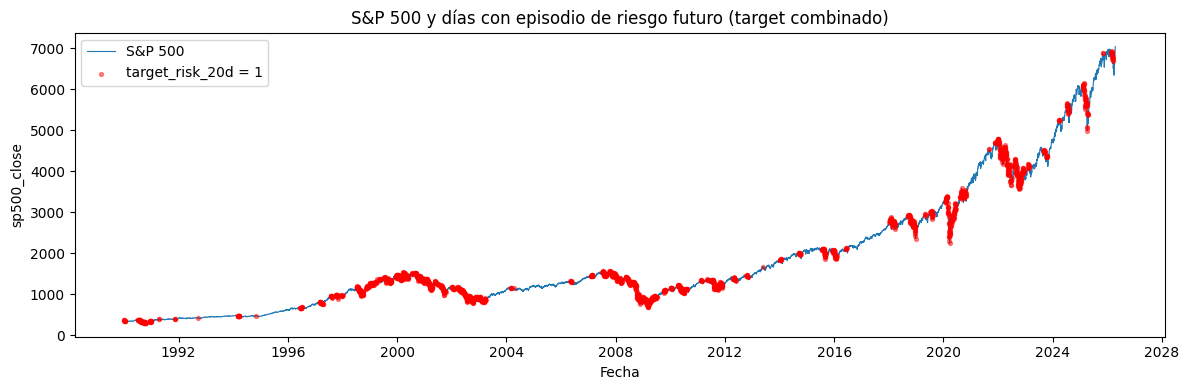

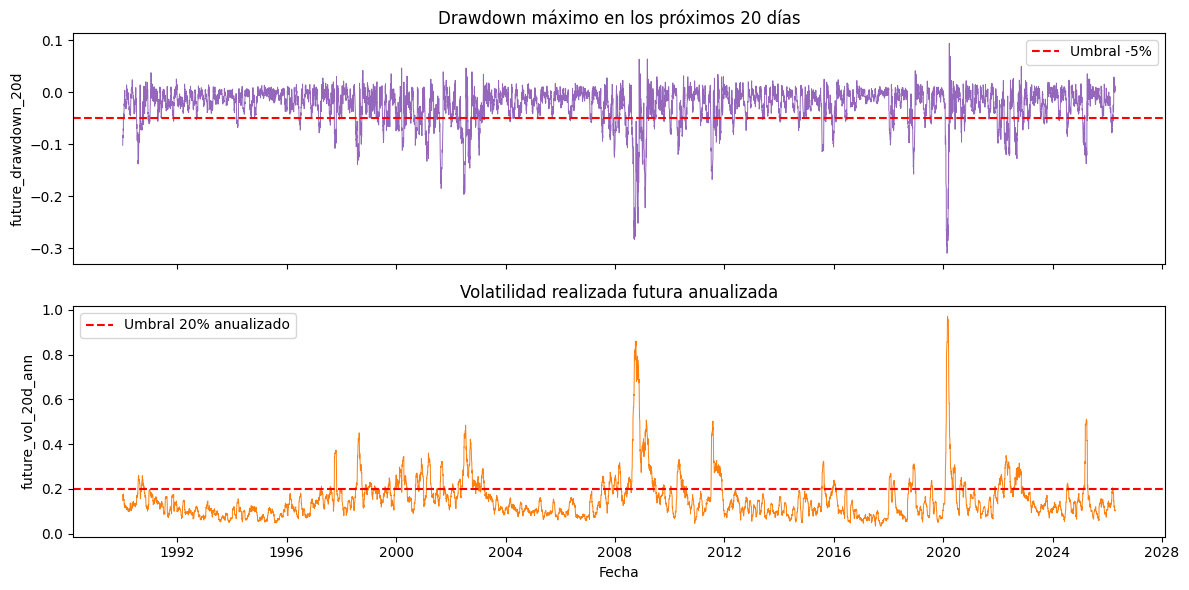

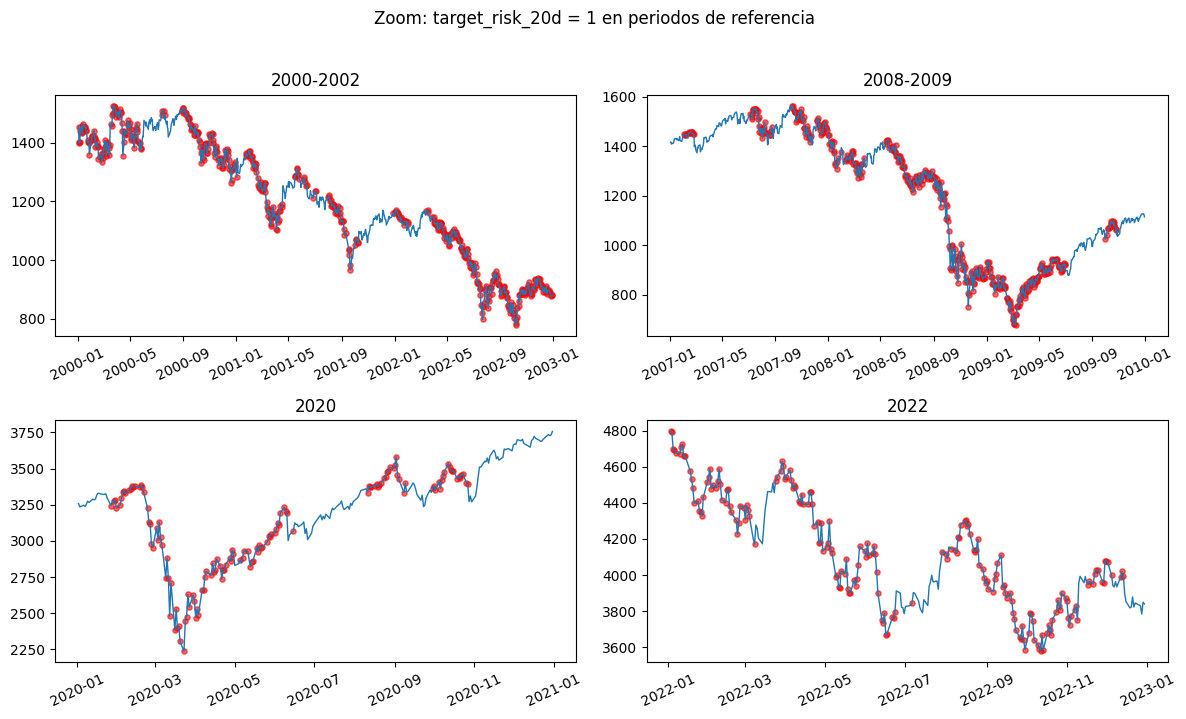

In [16]:
# Gráfico 1: S&P 500 y días con target_risk_20d = 1
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_target["date"], df_target["sp500_close"], color="tab:blue", linewidth=0.8, label="S&P 500")
risk_on = df_target[df_target["target_risk_20d"] == 1]
ax.scatter(risk_on["date"], risk_on["sp500_close"], color="red", s=8, alpha=0.45,
           label="target_risk_20d = 1", zorder=3)
ax.set_title("S&P 500 y días con episodio de riesgo futuro (target combinado)")
ax.set_xlabel("Fecha")
ax.set_ylabel("sp500_close")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Gráficos 2 y 3: magnitudes futuras con umbrales
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df_target["date"], df_target["future_drawdown_20d"], color="tab:purple", linewidth=0.7)
axes[0].axhline(DRAWDOWN_THRESHOLD, color="red", linestyle="--", label="Umbral -5%")
axes[0].set_ylabel("future_drawdown_20d")
axes[0].set_title("Drawdown máximo en los próximos 20 días")
axes[0].legend()

axes[1].plot(df_target["date"], df_target["future_vol_20d_ann"], color="tab:orange", linewidth=0.7)
axes[1].axhline(VOL_THRESHOLD_ANN, color="red", linestyle="--", label="Umbral 20% anualizado")
axes[1].set_ylabel("future_vol_20d_ann")
axes[1].set_xlabel("Fecha")
axes[1].set_title("Volatilidad realizada futura anualizada")
axes[1].legend()

plt.tight_layout()
plt.show()

# Zooms en crisis de referencia
periodos = [
    ("2000-2002", "2000-01-01", "2002-12-31"),
    ("2008-2009", "2007-01-01", "2009-12-31"),
    ("2020", "2020-01-01", "2020-12-31"),
    ("2022", "2022-01-01", "2022-12-31"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (titulo, ini, fin) in zip(axes.ravel(), periodos):
    sub = df_target[(df_target["date"] >= ini) & (df_target["date"] <= fin)]
    ax.plot(sub["date"], sub["sp500_close"], color="tab:blue", linewidth=1)
    sub_r = sub[sub["target_risk_20d"] == 1]
    ax.scatter(sub_r["date"], sub_r["sp500_close"], color="red", s=14, alpha=0.6)
    ax.set_title(titulo)
    ax.tick_params(axis="x", rotation=25)
plt.suptitle("Zoom: target_risk_20d = 1 en periodos de referencia", y=1.02)
plt.tight_layout()
plt.show()


## 7. Guardar el nuevo dataset

Exportamos a `dataset_with_target.csv`. El archivo `initial_market_dataset.csv` **no se toca**.


In [17]:
# Guardado: la columna 'date' ya está en el DataFrame; no exportamos el índice
df_target.to_csv(OUTPUT_PATH, index=False)
print("Dataset guardado en:", OUTPUT_PATH.resolve())
print("Filas exportadas:", len(df_target))
print("Columnas exportadas:", len(df_target.columns))


Dataset guardado en: /Users/victorcorralmorales/Documents/UNIR - IA/TFM/tfm-market-risk-ml/data/processed/dataset_with_target.csv
Filas exportadas: 9139
Columnas exportadas: 34


## 8. Comprobación final y columnas nuevas

Verificamos que el archivo existe y revisamos las primeras/últimas filas.


In [18]:
# Comprobar que el archivo se ha creado en disco
assert OUTPUT_PATH.exists(), f"No se encontró el archivo: {OUTPUT_PATH}"
print("OK: existe", OUTPUT_PATH.name)

# Recargar desde disco para validar la exportación
df_check = pd.read_csv(OUTPUT_PATH, parse_dates=["date"])

# Validaciones de la columna fecha (evitar duplicado date / date.1)
assert "date.1" not in df_check.columns, "Error: columna duplicada date.1 en el CSV"
assert pd.api.types.is_datetime64_any_dtype(df_check["date"]), "Error: 'date' no es datetime"
assert len(df_check.columns) == len(df_target.columns), (
    f"Columnas distintas: exportadas {len(df_target.columns)}, recargadas {len(df_check.columns)}"
)
print("OK: una única columna 'date' (tipo fecha) y mismo número de columnas que df_target")

print("\nResumen exportación / recarga:")
print("  Filas exportadas   :", len(df_target))
print("  Columnas exportadas:", len(df_target.columns))
print("  Columnas recargadas:", len(df_check.columns))

print("\nPrimeras filas:")
display(df_check.head())
print("\nÚltimas filas:")
display(df_check.tail())
print("\nInfo del dataset con target:")
df_check.info()

columnas_nuevas = [
    "future_drawdown_20d",
    "future_vol_20d_ann",
    "target_drawdown_20d_5",
    "target_volatility_20d_20",
    "target_risk_20d",
]
print("\nColumnas añadidas respecto al dataset base:")
for c in columnas_nuevas:
    print(" -", c)


OK: existe dataset_with_target.csv
OK: una única columna 'date' (tipo fecha) y mismo número de columnas que df_target

Resumen exportación / recarga:
  Filas exportadas   : 9139
  Columnas exportadas: 34
  Columnas recargadas: 34

Primeras filas:


,date,sp500_close,vix,treasury_10y,treasury_2y,treasury_3m,spread_10y_2y,spread_10y_3m,sp500_return_1d,sp500_return_5d,...,treasury_10y_change_20d,treasury_2y_change_20d,spread_10y_2y_change_20d,spread_10y_3m_change_20d,curve_inverted_10y_2y,future_drawdown_20d,future_vol_20d_ann,target_drawdown_20d_5,target_volatility_20d_20,target_risk_20d
0,1990-01-02,359.690002,17.24,7.94,7.87,7.83,0.07,0.11,NaN,NaN,...,NaN,NaN,NaN,NaN,0,-0.102060,0.147984,1,0,1
1,1990-01-03,358.760010,18.19,7.99,7.94,7.89,0.05,0.10,-0.002586,NaN,...,NaN,NaN,NaN,NaN,0,-0.099732,0.171083,1,0,1
2,1990-01-04,355.670013,19.22,7.98,7.92,7.84,0.06,0.14,-0.008613,NaN,...,NaN,NaN,NaN,NaN,0,-0.091911,0.170671,1,0,1
3,1990-01-05,352.200012,20.11,7.99,7.90,7.79,0.09,0.20,-0.009756,NaN,...,NaN,NaN,NaN,NaN,0,-0.082964,0.172954,1,0,1
4,1990-01-08,353.790009,20.26,8.02,7.90,7.79,0.12,0.23,0.004514,NaN,...,NaN,NaN,NaN,NaN,0,-0.087086,0.172068,1,0,1



Últimas filas:


,date,sp500_close,vix,treasury_10y,treasury_2y,treasury_3m,spread_10y_2y,spread_10y_3m,sp500_return_1d,sp500_return_5d,...,treasury_10y_change_20d,treasury_2y_change_20d,spread_10y_2y_change_20d,spread_10y_3m_change_20d,curve_inverted_10y_2y,future_drawdown_20d,future_vol_20d_ann,target_drawdown_20d_5,target_volatility_20d_20,target_risk_20d
9134,2026-04-10,6816.890137,19.23,4.31,3.81,3.69,0.50,0.62,-0.001139,0.035578,...,0.04,0.05,-0.01,0.07,0,0.010173,0.107597,0,0,0
9135,2026-04-13,6886.240234,19.12,4.30,3.78,3.71,0.52,0.59,0.010173,0.041503,...,0.02,0.05,-0.03,0.03,0,0.011783,0.105421,0,0,0
9136,2026-04-14,6967.379883,18.36,4.26,3.76,3.71,0.50,0.55,0.011783,0.052975,...,0.03,0.08,-0.05,0.04,0,0.007976,0.102496,0,0,0
9137,2026-04-15,7022.950195,18.17,4.29,3.76,3.71,0.53,0.58,0.007976,0.035404,...,0.09,0.08,0.01,0.10,0,0.002610,0.101411,0,0,0
9138,2026-04-16,7041.279785,17.94,4.32,3.78,3.70,0.54,0.62,0.002610,0.031741,...,0.06,0.02,0.04,0.09,0,0.003228,0.102768,0,0,0



Info del dataset con target:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9139 entries, 0 to 9138
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      9139 non-null   datetime64[ns]
 1   sp500_close               9139 non-null   float64       
 2   vix                       9139 non-null   float64       
 3   treasury_10y              9139 non-null   float64       
 4   treasury_2y               9139 non-null   float64       
 5   treasury_3m               9139 non-null   float64       
 6   spread_10y_2y             9139 non-null   float64       
 7   spread_10y_3m             9139 non-null   float64       
 8   sp500_return_1d           9138 non-null   float64       
 9   sp500_return_5d           9134 non-null   float64       
 10  sp500_return_20d          9119 non-null   float64       
 11  sp500_vol_20d             9119 non-null   float64   

## 9. Conclusiones

### Target creado
- **`target_risk_20d`** (binario): anticipa si en los **próximos 20 días hábiles** habrá:
  - una caída del S&P 500 de al menos **5%** desde el cierre de hoy, **o**
  - una volatilidad realizada futura anualizada de al menos **20%**.

### Dataset resultante
- Archivo: `data/processed/dataset_with_target.csv`
- Incluye todas las features del dataset base más las magnitudes futuras y los tres targets.
- Se eliminaron las filas finales sin horizonte futuro completo (típicamente 20 días).

### Adecuación para el TFM
- El target describe **riesgo futuro**, no precio ni retorno puntual.
- Umbrales **fijos** (5% y 20% anualizado) son interpretables y evitan fijar percentiles con información del test.
- El enfoque **combinado** captura correcciones fuertes y meses de alta inestabilidad.

### Pendiente antes de entrenar modelos
1. Tratar nulos iniciales de features rolling (recorte o imputación).
2. Definir partición temporal train / validación / test.
3. Elegir métricas (recall, F1, etc.) según el coste de falsas alarmas vs. crisis no detectadas.
4. Entrenar y comparar modelos (fase comparativa del TFM).

*Los valores numéricos concretos (filas, % de positivos) aparecen en la salida de las celdas anteriores al ejecutar este notebook.*
